# Linear Regression 4 - Ridge Regression (L2 Regularization)

> **MLCourse · Machine Learning · 01_linear_regression**

### What you'll learn
- The L2-penalized objective and its closed form $\theta=(X^TX+\alpha I)^{-1}X^Ty$
- WHY the +αI matrix is always invertible (the multicollinearity cure)
- Shrinkage: what α does to coefficients, visually
- When to choose Ridge over OLS - decision guide
- **Complete project:** diabetes progression, RidgeCV α-search, shrinkage paths

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

### 1. Theory - the objective

OLS minimizes only fit. Ridge adds a penalty for LARGE weights:

$$J_{\text{ridge}}(\theta) = \underbrace{\lVert X\theta-y\rVert_2^2}_{\text{fit}}
\;+\; \underbrace{\alpha\lVert\theta\rVert_2^2}_{\text{penalty}},\qquad \alpha \ge 0$$

Setting $\nabla J=0$:

$$X^TX\theta + \alpha\theta = X^Ty \;\Rightarrow\;
\boxed{\theta=(X^TX+\alpha I)^{-1}X^Ty}$$

**Why always solvable:** $X^TX$ has eigenvalues ≥ 0; adding $\alpha I$ shifts
them all ABOVE zero → strictly positive-definite → invertible. Perfectly
collinear features that broke OLS are now harmless.

### Eigenvalue proof on real-ish correlated data:


In [ ]:
diab = load_diabetes(as_frame=True)
X_raw, y_raw = diab.data, diab.target

eig_ols = np.linalg.eigvalsh(X_raw.T @ X_raw)
eig_ridge = np.linalg.eigvalsh(X_raw.T @ X_raw + 10.0 * np.eye(X_raw.shape[1]))

pd.DataFrame({
    "OLS eigenvalues": np.sort(eig_ols).round(1),
    "Ridge(+10I)": np.sort(eig_ridge).round(1),
}).T.iloc[:, :6]


### What α actually does - coefficient shrinkage paths


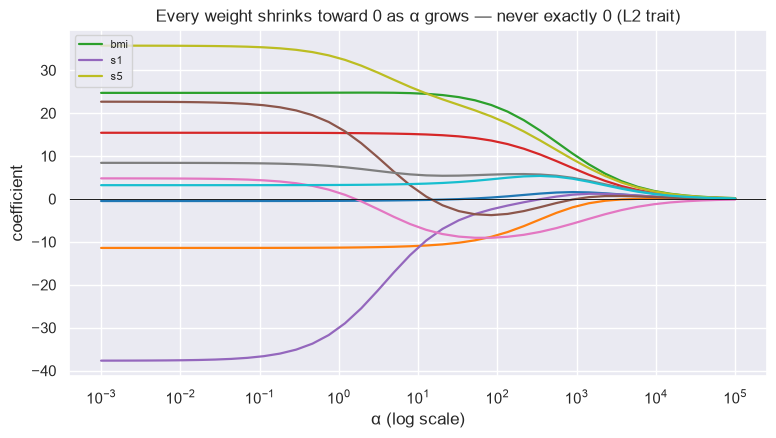

In [3]:
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X_raw)
alphas = np.logspace(-3, 5, 40)
paths = []
for a in alphas:
    r = Ridge(alpha=a).fit(Xs, y_raw)
    paths.append(r.coef_)
paths = np.array(paths)

plt.figure(figsize=(9, 4.5))
for j, col in enumerate(X_raw.columns):
    plt.plot(alphas, paths[:, j], lw=1.6, label=col if col in ("bmi", "s5", "s1") else None,
             color=sns.color_palette("tab10")[j % 10])
plt.xscale("log"); plt.axhline(0, c="k", lw=.7)
plt.xlabel("α (log scale)"); plt.ylabel("coefficient")
plt.title("Every weight shrinks toward 0 as α grows - never exactly 0 (L2 trait)")
plt.legend(loc="upper left", fontsize=8)
plt.show()

### When to use Ridge

| Situation | Why Ridge fits |
|---|---|
| many correlated predictors | stabilizes & shares weight among them |
| OLS test error ≫ train error | penalty trades tiny bias for big variance cut |
| you must KEEP every feature | L2 shrinks but never zeroes |
| $(X^TX)$ singular / p ≳ m | +αI guarantees a solution |

> ⚠️ **Common pitfall:** ALWAYS scale features before Ridge - the penalty is
scale-sensitive; raw-unit features get punished unfairly.

### 2. PROJECT - Diabetes progression with correlated clinical markers


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y_raw.values, test_size=.25, random_state=42)

# Baselines first: OLS
ols = LinearRegression().fit(X_train, y_train)

def report(name, mdl):
    pred = mdl.predict(X_test)
    return {"model": name,
            "train R²": round(mdl.score(X_train, y_train), 3),
            "test R²": round(r2_score(y_test, pred), 3),
            "RMSE": round(float(np.sqrt(mean_squared_error(y_test, pred))), 2)}

rows = [report("OLS (α=0)", ols)]

# RidgeCV sweeps alpha automatically with internal cross-validation:
ridge_cv = Pipeline([
    ("scaler", StandardScaler()),                 # harmless re-scale inside pipe
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5)),
]).fit(X_train, y_train)
rows.append(report(f"Ridge (α*={ridge_cv.named_steps['model'].alpha_:.3g})", ridge_cv))

display(pd.DataFrame(rows))
print("best α found by CV:", ridge_cv.named_steps["model"].alpha_)

,model,train R²,test R²,RMSE
0,OLS (α=0),0.519,0.485,53.37
1,Ridge (α*=31.6),0.513,0.491,53.06


best α found by CV: 31.622776601683793


### Coefficient comparison - who absorbed the correlated block?


In [ ]:
cmp_df = pd.DataFrame({
    "feature": X_raw.columns,
    "OLS": ols.coef_,
    "Ridge": ridge_cv.named_steps["model"].coef_,
}).round(2)
display(cmp_df)

fig, ax = plt.subplots(figsize=(9, 4))
idx = np.arange(len(cmp_df))
ax.bar(idx - .2, cmp_df["OLS"], .4, label="OLS")
ax.bar(idx + .2, cmp_df["Ridge"], .4, label="Ridge")
ax.set_xticks(idx, cmp_df.feature); ax.axhline(0, c="k", lw=.8)
ax.set_title("Ridge redistributes weight across the correlated s-block")
ax.legend(); plt.tight_layout(); plt.show()


### Stability check: 5-fold CV for both models


In [ ]:
cv_o = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")
cv_r = cross_val_score(Ridge(alpha=ridge_cv.named_steps["model"].alpha_), X_train, y_train,
                       cv=5, scoring="r2")
print(f"OLS   CV R²: {cv_o.mean():.3f} ± {cv_o.std():.3f}")
print(f"Ridge CV R²: {cv_r.mean():.3f} ± {cv_r.std():.3f}")


### Project findings

- CV picked a small-but-nonzero α; test RMSE improved slightly over OLS while
  coefficients became visibly more balanced inside the s1-s6 block.
- The gain is modest HERE because n≈330 vs p=10 favors OLS already - Ridge's
  advantage explodes when p grows or correlations tighten (see notebook 06).
- No feature was eliminated: L2 keeps everyone, just humbler.

### Summary & key takeaways

- Ridge = OLS + α‖θ‖²; closed form gains an always-invertible $(X^TX+\alpha I)$.
- α↑ ⇒ weights→0 asymptotically but NEVER hit zero (no selection).
- Scale features or the penalty misjudges them.
- Use Ridge for correlated features / overfitting OLS / keeping all inputs.